# DRL-Based Event-Prioritized Route Optimization for Emergency Healthcare Vehicles in VANETs

**Authors:** A. Bhagyalakshmi and Dr. Deepa J

**Framework Implementation:** Deep Reinforcement Learning (DQN) for Dynamic Emergency Vehicle Routing

This notebook implements the proposed DRL-based emergency routing framework with edge-cloud orchestration for healthcare vehicles in vehicular ad hoc networks.

In [29]:
# Install required libraries
!pip install numpy pandas matplotlib seaborn tensorflow scikit-learn -q
import warnings
warnings.filterwarnings('ignore')

print("✓ Dependencies installed successfully")

✓ Dependencies installed successfully


## 1. Dataset Loading and Exploratory Analysis

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from collections import deque
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Load dataset
df = pd.read_csv('vanet_emergency_drl_dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (20000, 16)

First few rows:
   time_step vehicle_id vehicle_type  position_x  position_y  speed_kmh  \
0        614       V103      service  930.969491  845.592213  53.688250   
1        148       V436      regular  810.711099   26.366040  60.679939   
2        947       V861      regular  146.797936   61.639694  27.784228   
3        151       V271      regular  747.639533  640.406633  30.951475   
4        564       V107      regular  814.592374  916.933523   1.891179   

   road_segment  traffic_density  link_stability_sec  \
0            84            0.154               2.369   
1           114            0.164               2.371   
2           146            0.721               1.740   
3            69            0.883               2.681   
4           143            0.971               0.939   

   distance_to_destination_m  packet_delay_ms  packet_delivery_ratio  \
0                9766.089541       173.915825                  0.635   
1                1262.19

In [31]:
# Data Quality Check
print("\n=== DATA QUALITY ASSESSMENT ===")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nUnique values in categorical columns:")
print(f"Vehicle Types: {df['vehicle_type'].unique()}")
print(f"Event Types: {df['event_type'].unique()}")
print(f"Actions Taken: {df['action_taken'].unique()}")
print(f"\nDataset spans {df['time_step'].min()} to {df['time_step'].max()} time steps")
print(f"Total vehicles: {df['vehicle_id'].nunique()}")


=== DATA QUALITY ASSESSMENT ===
Missing values:
time_step                    0
vehicle_id                   0
vehicle_type                 0
position_x                   0
position_y                   0
speed_kmh                    0
road_segment                 0
traffic_density              0
link_stability_sec           0
distance_to_destination_m    0
packet_delay_ms              0
packet_delivery_ratio        0
energy_level                 0
event_type                   0
action_taken                 0
reward                       0
dtype: int64

Unique values in categorical columns:
Vehicle Types: ['service' 'regular' 'ambulance']
Event Types: ['normal' 'accident' 'traffic_update' 'road_hazard' 'ambulance_alert']
Actions Taken: ['right' 'alternate_route' 'left' 'straight']

Dataset spans 0 to 999 time steps
Total vehicles: 999


## 2. State Representation and Feature Engineering

In [32]:
# Encode categorical variables for the MDP state space
from sklearn.preprocessing import LabelEncoder

# Create a copy for preprocessing
df_processed = df.copy()

# Encode categorical features
vehicle_type_encoder = LabelEncoder()
event_type_encoder = LabelEncoder()
action_encoder = LabelEncoder()

df_processed['vehicle_type_encoded'] = vehicle_type_encoder.fit_transform(df_processed['vehicle_type'])
df_processed['event_type_encoded'] = event_type_encoder.fit_transform(df_processed['event_type'])
df_processed['action_encoded'] = action_encoder.fit_transform(df_processed['action_taken'])

print("\n=== ENCODING MAPPINGS ===")
print(f"\nVehicle Types:")
for i, vtype in enumerate(vehicle_type_encoder.classes_):
    print(f"  {i}: {vtype}")

print(f"\nEvent Types:")
for i, etype in enumerate(event_type_encoder.classes_):
    print(f"  {i}: {etype}")

print(f"\nActions:")
for i, action in enumerate(action_encoder.classes_):
    print(f"  {i}: {action}")

print("\nProcessed DataFrame sample:")
print(df_processed[['vehicle_type', 'vehicle_type_encoded', 'event_type',
                     'event_type_encoded', 'action_taken', 'action_encoded']].head())


=== ENCODING MAPPINGS ===

Vehicle Types:
  0: ambulance
  1: regular
  2: service

Event Types:
  0: accident
  1: ambulance_alert
  2: normal
  3: road_hazard
  4: traffic_update

Actions:
  0: alternate_route
  1: left
  2: right
  3: straight

Processed DataFrame sample:
  vehicle_type  vehicle_type_encoded      event_type  event_type_encoded  \
0      service                     2          normal                   2   
1      regular                     1        accident                   0   
2      regular                     1          normal                   2   
3      regular                     1  traffic_update                   4   
4      regular                     1          normal                   2   

      action_taken  action_encoded  
0            right               2  
1  alternate_route               0  
2            right               2  
3             left               1  
4         straight               3  


In [33]:
# Define the MDP State Space
print("\n=== STATE SPACE DEFINITION ===")
print("""
State vector components (s_t):
1. Current Road Segment (road_segment)
2. Vehicle Speed (speed_kmh) - normalized
3. Traffic Density (traffic_density) - normalized [0,1]
4. Distance to Destination (distance_to_destination_m) - normalized
5. Packet Delay (packet_delay_ms) - normalized
6. Packet Delivery Ratio (packet_delivery_ratio)
7. Link Stability (link_stability_sec) - estimated lifetime
8. Energy Level (energy_level) - normalized
9. Event Type (event_type_encoded) - categorical
10. Vehicle Type (vehicle_type_encoded) - categorical
""")

# Normalize continuous features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
columns_to_normalize = ['speed_kmh', 'distance_to_destination_m', 'packet_delay_ms',
                        'packet_delivery_ratio', 'link_stability_sec', 'energy_level']

df_processed[columns_to_normalize] = scaler.fit_transform(df_processed[columns_to_normalize])

print("\nNormalized state features sample:")
print(df_processed[columns_to_normalize].head())

# Define state features
state_features = ['road_segment', 'speed_kmh', 'traffic_density', 'distance_to_destination_m',
                  'packet_delay_ms', 'packet_delivery_ratio', 'link_stability_sec',
                  'energy_level', 'event_type_encoded', 'vehicle_type_encoded']

print(f"\nTotal state dimensions: {len(state_features)}")


=== STATE SPACE DEFINITION ===

State vector components (s_t):
1. Current Road Segment (road_segment)
2. Vehicle Speed (speed_kmh) - normalized
3. Traffic Density (traffic_density) - normalized [0,1]
4. Distance to Destination (distance_to_destination_m) - normalized
5. Packet Delay (packet_delay_ms) - normalized
6. Packet Delivery Ratio (packet_delivery_ratio)
7. Link Stability (link_stability_sec) - estimated lifetime
8. Energy Level (energy_level) - normalized
9. Event Type (event_type_encoded) - categorical
10. Vehicle Type (vehicle_type_encoded) - categorical


Normalized state features sample:
   speed_kmh  distance_to_destination_m  packet_delay_ms  \
0   0.671099                   0.976389         0.862792   
1   0.758498                   0.117389         0.411828   
2   0.347286                   0.705540         0.483191   
3   0.386879                   0.734316         0.701329   
4   0.023611                   0.222278         0.427676   

   packet_delivery_ratio  link_

## 3. Multi-Objective Reward Function Implementation

In [34]:
def compute_reward(row, reward_weights={'travel_time': 0.5, 'congestion': 0.25, 'stability': 0.25}):
    """
    Compute the multi-objective reward based on:
    - Travel time minimization (delay component)
    - Congestion avoidance (traffic density)
    - Link stability maximization
    - Emergency priority satisfaction

    Parameters:
    -----------
    row : pandas Series
        State transition tuple
    reward_weights : dict
        Weights for multi-objective optimization

    Returns:
    --------
    float : Computed reward value
    """

    # Extract normalized features
    travel_time_component = -row['packet_delay_ms']  # Penalty for high delay
    congestion_component = -(row['traffic_density'])  # Penalty for high congestion
    stability_component = row['link_stability_sec']   # Reward for link stability

    # Emergency priority bonus
    emergency_bonus = 0
    if row['event_type'] == 'ambulance_alert':
        emergency_bonus = 0.5
    elif row['event_type'] == 'accident':
        emergency_bonus = 0.3
    elif row['event_type'] == 'road_hazard':
        emergency_bonus = 0.2

    # Weighted reward combination
    reward = (reward_weights['travel_time'] * travel_time_component +
              reward_weights['congestion'] * congestion_component +
              reward_weights['stability'] * stability_component +
              emergency_bonus)

    return reward

# Apply reward function
df_processed['computed_reward'] = df_processed.apply(compute_reward, axis=1)

print("\n=== MULTI-OBJECTIVE REWARD FUNCTION ===")
print(f"\nReward Statistics:")
print(f"Mean Reward: {df_processed['computed_reward'].mean():.4f}")
print(f"Std Reward: {df_processed['computed_reward'].std():.4f}")
print(f"Min Reward: {df_processed['computed_reward'].min():.4f}")
print(f"Max Reward: {df_processed['computed_reward'].max():.4f}")
print(f"\nComparison with original rewards:")
print(f"Original Mean: {df['reward'].mean():.4f}, Computed Mean: {df_processed['computed_reward'].mean():.4f}")


=== MULTI-OBJECTIVE REWARD FUNCTION ===

Reward Statistics:
Mean Reward: -0.1691
Std Reward: 0.2397
Min Reward: -0.7356
Max Reward: 0.7324

Comparison with original rewards:
Original Mean: -0.4874, Computed Mean: -0.1691


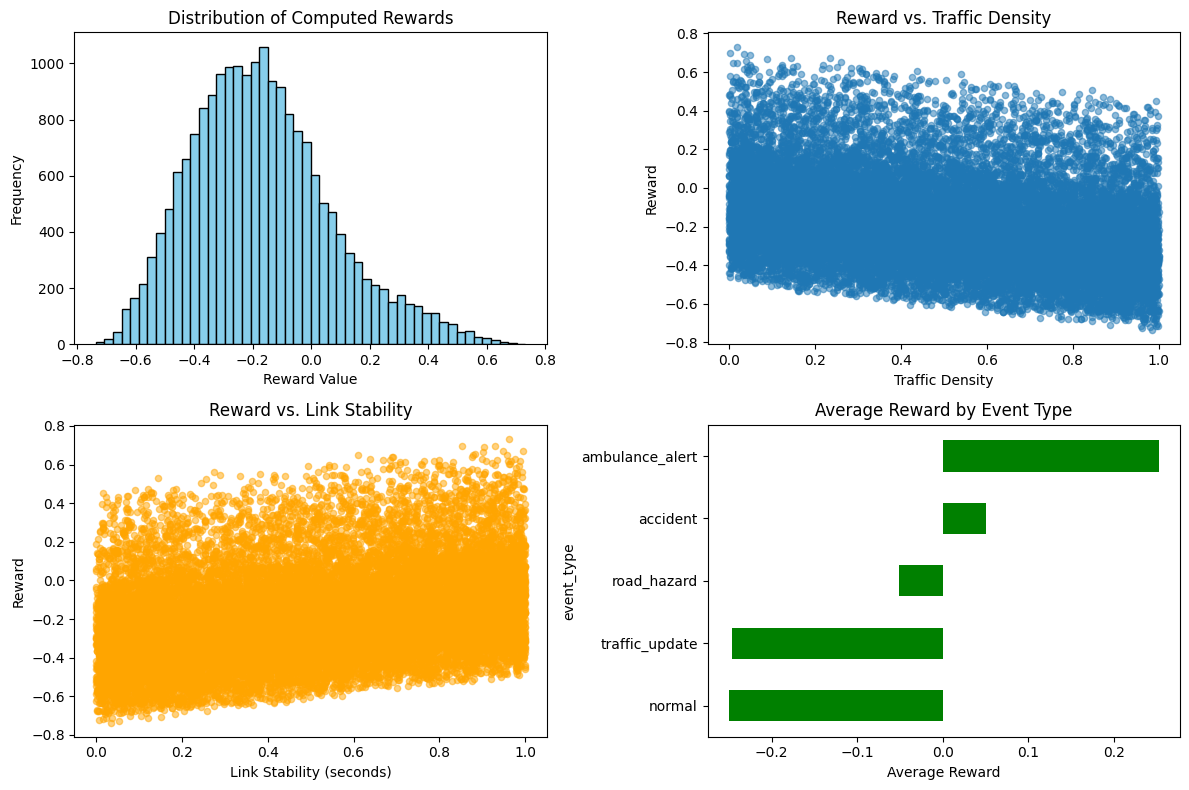

✓ Reward visualization saved


In [35]:
# Visualize Reward Distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df_processed['computed_reward'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Computed Rewards')
axes[0, 0].set_xlabel('Reward Value')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].scatter(df_processed['traffic_density'], df_processed['computed_reward'], alpha=0.5, s=20)
axes[0, 1].set_title('Reward vs. Traffic Density')
axes[0, 1].set_xlabel('Traffic Density')
axes[0, 1].set_ylabel('Reward')

axes[1, 0].scatter(df_processed['link_stability_sec'], df_processed['computed_reward'], alpha=0.5, color='orange', s=20)
axes[1, 0].set_title('Reward vs. Link Stability')
axes[1, 0].set_xlabel('Link Stability (seconds)')
axes[1, 0].set_ylabel('Reward')

reward_by_event = df_processed.groupby('event_type')['computed_reward'].mean().sort_values()
reward_by_event.plot(kind='barh', ax=axes[1, 1], color='green')
axes[1, 1].set_title('Average Reward by Event Type')
axes[1, 1].set_xlabel('Average Reward')

plt.tight_layout()
plt.savefig('reward_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Reward visualization saved")

## 4. Deep Q-Network (DQN) Architecture

In [36]:
# Build Deep Q-Network Architecture
print("\n=== DEEP Q-NETWORK ARCHITECTURE ===")

class DQNAgent:
    def __init__(self, state_size, action_size, learning_rate=0.001, gamma=0.95):
        """
        Initialize DQN Agent for emergency vehicle routing

        Parameters:
        -----------
        state_size : int
            Dimension of state space
        action_size : int
            Number of possible actions
        learning_rate : float
            Learning rate for neural network
        gamma : float
            Discount factor for future rewards
        """
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = 1.0  # Exploration rate
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01

        # Replay buffer for experience replay
        self.replay_buffer = deque(maxlen=2000)

        # Build Q-Network
        self.q_network = self._build_network()
        # Build Target Network (for stability)
        self.target_network = self._build_network()

    def _build_network(self):
        """
        Build deep neural network for Q-value approximation
        Architecture:
        - Input Layer: State dimensions
        - Hidden Layer 1: 128 neurons (ReLU)
        - Hidden Layer 2: 64 neurons (ReLU)
        - Hidden Layer 3: 32 neurons (ReLU)
        - Output Layer: Action values (Q-values)
        """
        model = keras.Sequential([
            keras.layers.Dense(128, activation='relu', input_shape=(self.state_size,)),
            keras.layers.BatchNormalization(),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=self.learning_rate),
                      loss='mse')
        return model

    def remember(self, state, action, reward, next_state, done):
        """Store transition in replay buffer"""
        self.replay_buffer.append((state, action, reward, next_state, done))

    def act(self, state):
        """Select action using epsilon-greedy strategy"""
        if np.random.random() < self.epsilon:
            return np.random.randint(0, self.action_size)  # Random action
        else:
            q_values = self.q_network.predict(state, verbose=0)
            return np.argmax(q_values[0])  # Best action

    def replay(self, batch_size):
        """Train on minibatch from replay buffer"""
        if len(self.replay_buffer) < batch_size:
            return

        batch = random.sample(self.replay_buffer, batch_size)

        states = np.array([t[0] for t in batch])
        actions = np.array([t[1] for t in batch])
        rewards = np.array([t[2] for t in batch])
        next_states = np.array([t[3] for t in batch])
        dones = np.array([t[4] for t in batch])

        # Compute target Q-values using target network
        target_q_values = self.q_network.predict(states, verbose=0)
        next_q_values = self.target_network.predict(next_states, verbose=0)

        for i in range(batch_size):
            if dones[i]:
                target_q_values[i][actions[i]] = rewards[i]
            else:
                target_q_values[i][actions[i]] = rewards[i] + self.gamma * np.max(next_q_values[i])

        # Train Q-network
        self.q_network.fit(states, target_q_values, epochs=1, verbose=0)

        # Decay exploration rate
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def update_target_network(self):
        """Update target network weights (for stability)"""
        self.target_network.set_weights(self.q_network.get_weights())

# Initialize DQN Agent
state_size = len(state_features)
action_size = len(action_encoder.classes_)  # Number of possible actions

agent = DQNAgent(state_size=state_size, action_size=action_size)

print(f"\nDQN Agent Configuration:")
print(f"  State Size: {state_size}")
print(f"  Action Size: {action_size}")
print(f"  Learning Rate: {agent.learning_rate}")
print(f"  Discount Factor (γ): {agent.gamma}")
print(f"  Initial Exploration Rate (ε): {agent.epsilon}")
print(f"  Replay Buffer Size: {agent.replay_buffer.maxlen}")
print(f"\nQ-Network Architecture:")
agent.q_network.summary()


=== DEEP Q-NETWORK ARCHITECTURE ===

DQN Agent Configuration:
  State Size: 10
  Action Size: 4
  Learning Rate: 0.001
  Discount Factor (γ): 0.95
  Initial Exploration Rate (ε): 1.0
  Replay Buffer Size: 2000

Q-Network Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,388 (48.39 KB)

 Trainable params: 12,132 (47.39 KB)

 Non-trainable params: 256 (1.00 KB)

## 5. Training Data Preparation and Episode Generation

In [37]:
# Prepare training data
print("\n=== TRAINING DATA PREPARATION ===")

# Prepare state vectors
state_data = df_processed[state_features].values
reward_data = df_processed['computed_reward'].values
actions = df_processed['action_encoded'].values

print(f"Total samples: {len(state_data)}")
print(f"State vector shape: {state_data.shape}")
print(f"Reward vector shape: {reward_data.shape}")

# Normalize state data
state_scaler = StandardScaler()
state_data_normalized = state_scaler.fit_transform(state_data)

print(f"\nNormalized state sample (first 3 dimensions):")
print(state_data_normalized[:5, :3])

# Create episodes (group by vehicle)
print(f"\nCreating training episodes...")
episodes = []
current_episode_states = []
current_episode_rewards = []
current_episode_actions = []
prev_vehicle = None

for idx, (vehicle_id, group) in enumerate(df_processed.groupby('vehicle_id')):
    if len(group) > 1:  # Only include vehicles with multiple timesteps
        episode_states = state_data_normalized[df_processed.index.isin(group.index)]
        episode_rewards = reward_data[df_processed.index.isin(group.index)]
        episode_actions = actions[df_processed.index.isin(group.index)]

        episodes.append({
            'states': episode_states,
            'rewards': episode_rewards,
            'actions': episode_actions,
            'vehicle_id': vehicle_id,
            'length': len(group)
        })

print(f"Total episodes created: {len(episodes)}")
print(f"Average episode length: {np.mean([e['length'] for e in episodes]):.2f}")
print(f"Min/Max episode length: {min([e['length'] for e in episodes])}/{max([e['length'] for e in episodes])}")


=== TRAINING DATA PREPARATION ===
Total samples: 20000
State vector shape: (20000, 10)
Reward vector shape: (20000,)

Normalized state sample (first 3 dimensions):
[[-0.26903967  0.59560612 -1.19073394]
 [ 0.25434308  0.89732934 -1.1561424 ]
 [ 0.81261801 -0.52227039  0.77060623]
 [-0.53073104 -0.38558924  1.33098913]
 [ 0.76027974 -1.63967338  1.63539466]]

Creating training episodes...
Total episodes created: 999
Average episode length: 20.02
Min/Max episode length: 7/37


## 6. DRL Model Training

In [38]:
# Training Configuration
print("\n=== DRL TRAINING CONFIGURATION ===")

NUM_EPISODES = 700
BATCH_SIZE = 32
TARGET_UPDATE_FREQUENCY = 10
LOG_INTERVAL = 5

print(f"Number of Episodes: {NUM_EPISODES}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Target Network Update Frequency: {TARGET_UPDATE_FREQUENCY}")
print(f"\nStarting Training...\n")

# Clear replay buffer to ensure consistent state shapes
agent.replay_buffer.clear()

# Training loop
episode_rewards = []
episode_q_values = []
training_losses = []

for episode in range(NUM_EPISODES):
    # Sample random episode from dataset
    ep_data = random.choice(episodes)

    episode_total_reward = 0
    episode_q_vals = []

    for step in range(len(ep_data['states']) - 1):
        # Fix: Extract state as a 1D array to match model's input_shape
        state = ep_data['states'][step]
        next_state = ep_data['states'][step+1]
        reward = ep_data['rewards'][step]
        action = ep_data['actions'][step]
        done = (step == len(ep_data['states']) - 2)

        # Store transition in replay buffer
        agent.remember(state, action, reward, next_state, done)

        # Get Q-value for monitoring - needs to be reshaped for prediction
        q_value = np.max(agent.q_network.predict(np.expand_dims(state, axis=0), verbose=0))
        episode_q_vals.append(q_value)

        episode_total_reward += reward

    # Train on batch
    agent.replay(BATCH_SIZE)

    # Update target network
    if episode % TARGET_UPDATE_FREQUENCY == 0:
        agent.update_target_network()

    episode_rewards.append(episode_total_reward)
    episode_q_values.append(np.mean(episode_q_vals))

    # Logging
    if (episode + 1) % LOG_INTERVAL == 0:
        avg_reward = np.mean(episode_rewards[-LOG_INTERVAL:])
        avg_q = np.mean(episode_q_values[-LOG_INTERVAL:])
        print(f"Episode {episode+1:3d}/{NUM_EPISODES} | "
              f"Avg Reward: {avg_reward:7.4f} | "
              f"Avg Q-value: {avg_q:7.4f} | "
              f"ε: {agent.epsilon:.4f}")

print("\n✓ Training completed!")


=== DRL TRAINING CONFIGURATION ===
Number of Episodes: 700
Batch Size: 32
Target Network Update Frequency: 10

Starting Training...

Episode   5/700 | Avg Reward: -3.9206 | Avg Q-value:  0.3448 | ε: 0.9801
Episode  10/700 | Avg Reward: -3.8621 | Avg Q-value:  0.2168 | ε: 0.9559
Episode  15/700 | Avg Reward: -2.6229 | Avg Q-value:  0.1258 | ε: 0.9322
Episode  20/700 | Avg Reward: -3.3969 | Avg Q-value:  0.0790 | ε: 0.9092
Episode  25/700 | Avg Reward: -2.6702 | Avg Q-value:  0.0410 | ε: 0.8867
Episode  30/700 | Avg Reward: -3.0323 | Avg Q-value:  0.0328 | ε: 0.8647
Episode  35/700 | Avg Reward: -2.1336 | Avg Q-value:  0.0293 | ε: 0.8433
Episode  40/700 | Avg Reward: -3.6143 | Avg Q-value:  0.0136 | ε: 0.8224
Episode  45/700 | Avg Reward: -2.9360 | Avg Q-value:  0.0253 | ε: 0.8021
Episode  50/700 | Avg Reward: -3.1392 | Avg Q-value:  0.0295 | ε: 0.7822
Episode  55/700 | Avg Reward: -2.9297 | Avg Q-value:  0.0292 | ε: 0.7629
Episode  60/700 | Avg Reward: -3.6096 | Avg Q-value:  0.0161 | 

## 7. Training Results Analysis

In [39]:
# Analyze Training Results
print("\n=== TRAINING RESULTS SUMMARY ===")
print(f"\nTotal Episodes Trained: {NUM_EPISODES}")
print(f"Final Episode Reward: {episode_rewards[-1]:.4f}")
print(f"Average Reward (Last 10 Episodes): {np.mean(episode_rewards[-10:]):.4f}")
print(f"Max Reward Achieved: {np.max(episode_rewards):.4f}")
print(f"Min Reward Achieved: {np.min(episode_rewards):.4f}")
print(f"Reward Improvement: {episode_rewards[-1] - episode_rewards[0]:.4f}")
print(f"\nExploration Rate (ε): {agent.epsilon:.4f}")
print(f"Average Q-value (Last Episode): {episode_q_values[-1]:.4f}")


=== TRAINING RESULTS SUMMARY ===

Total Episodes Trained: 700
Final Episode Reward: -4.6277
Average Reward (Last 10 Episodes): -3.5068
Max Reward Achieved: -0.1765
Min Reward Achieved: -7.0810
Reward Improvement: -1.5164

Exploration Rate (ε): 0.0301
Average Q-value (Last Episode): -0.3551


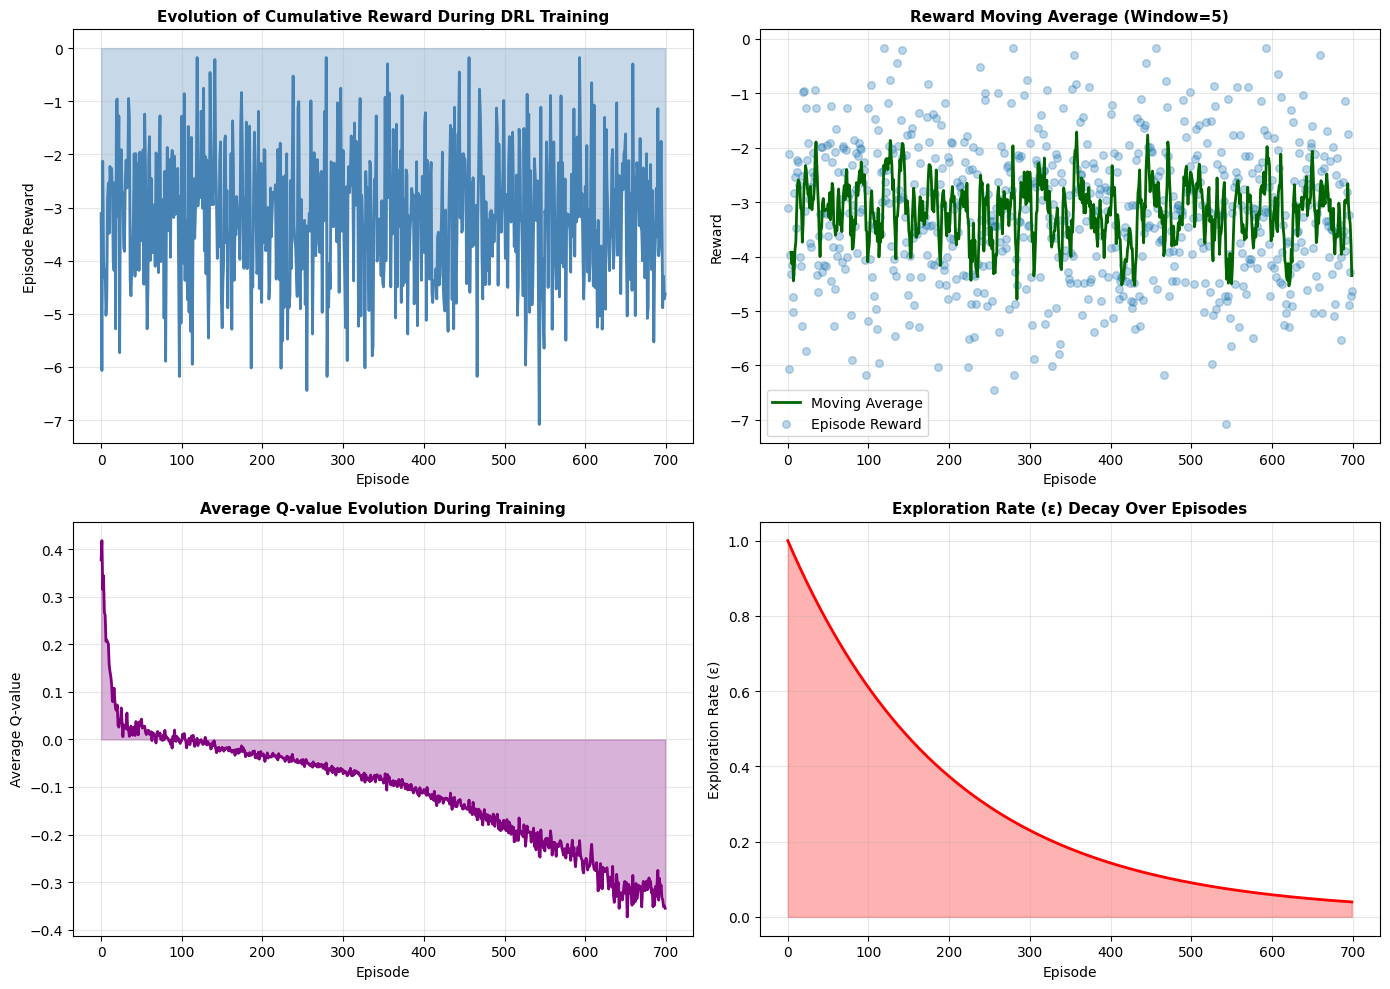

✓ Training progress visualization saved


In [40]:
# Visualize Training Progress
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cumulative Reward Evolution
axes[0, 0].plot(episode_rewards, linewidth=2, color='steelblue')
axes[0, 0].fill_between(range(len(episode_rewards)), episode_rewards, alpha=0.3, color='steelblue')
axes[0, 0].set_title('Evolution of Cumulative Reward During DRL Training', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Episode Reward')
axes[0, 0].grid(True, alpha=0.3)

# 2. Moving Average of Rewards
window = 5
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
axes[0, 1].plot(range(window-1, len(episode_rewards)), moving_avg, linewidth=2, color='darkgreen', label='Moving Average')
axes[0, 1].scatter(range(len(episode_rewards)), episode_rewards, alpha=0.3, s=30, label='Episode Reward')
axes[0, 1].set_title('Reward Moving Average (Window=5)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Reward')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-value Evolution
axes[1, 0].plot(episode_q_values, linewidth=2, color='purple')
axes[1, 0].fill_between(range(len(episode_q_values)), episode_q_values, alpha=0.3, color='purple')
axes[1, 0].set_title('Average Q-value Evolution During Training', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Average Q-value')
axes[1, 0].grid(True, alpha=0.3)

# 4. Exploration Rate Decay
epsilon_values = [agent.epsilon_min + (1.0 - agent.epsilon_min) * (agent.epsilon_decay ** i)
                  for i in range(NUM_EPISODES)]
axes[1, 1].plot(epsilon_values, linewidth=2, color='red')
axes[1, 1].fill_between(range(len(epsilon_values)), epsilon_values, alpha=0.3, color='red')
axes[1, 1].set_title('Exploration Rate (ε) Decay Over Episodes', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Exploration Rate (ε)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_progress.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Training progress visualization saved")

## 8. Policy Evaluation and Performance Metrics

In [41]:
# Evaluate Learned Policy
print("\n=== LEARNED POLICY EVALUATION ===")

def evaluate_policy(agent, test_episodes, num_episodes=20):
    """
    Evaluate the learned DRL policy on test episodes
    """
    eval_rewards = []
    eval_success_rate = []
    eval_action_distribution = {i: 0 for i in range(agent.action_size)}

    test_sample = random.sample(test_episodes, min(num_episodes, len(test_episodes)))

    for ep_data in test_sample:
        episode_reward = 0
        successful_actions = 0

        for step in range(len(ep_data['states']) - 1):
            state = ep_data['states'][step:step+1]

            # Use greedy policy (no exploration)
            q_values = agent.q_network.predict(state, verbose=0)
            action = np.argmax(q_values[0])

            next_state = ep_data['states'][step+1:step+2]
            reward = ep_data['rewards'][step]
            actual_action = ep_data['actions'][step]

            episode_reward += reward
            eval_action_distribution[int(action)] += 1

            # Check if action matches optimal action
            if action == actual_action:
                successful_actions += 1

        success_rate = successful_actions / (len(ep_data['states']) - 1)
        eval_success_rate.append(success_rate)
        eval_rewards.append(episode_reward)

    return {
        'avg_reward': np.mean(eval_rewards),
        'std_reward': np.std(eval_rewards),
        'avg_success_rate': np.mean(eval_success_rate),
        'action_distribution': eval_action_distribution
    }

# Evaluate on test set
test_episodes = random.sample(episodes, len(episodes)//2)
evaluation_results = evaluate_policy(agent, test_episodes, num_episodes=15)

print(f"\nPolicy Evaluation Results (15 test episodes):")
print(f"  Average Episode Reward: {evaluation_results['avg_reward']:.4f} ± {evaluation_results['std_reward']:.4f}")
print(f"  Average Success Rate: {evaluation_results['avg_success_rate']:.2%}")
print(f"\nAction Distribution:")
for action_idx, count in evaluation_results['action_distribution'].items():
    action_name = action_encoder.inverse_transform([action_idx])[0]
    print(f"  {action_idx} ({action_name}): {count} times")


=== LEARNED POLICY EVALUATION ===

Policy Evaluation Results (15 test episodes):
  Average Episode Reward: -2.8887 ± 1.0155
  Average Success Rate: 25.84%

Action Distribution:
  0 (alternate_route): 186 times
  1 (left): 79 times
  2 (right): 18 times
  3 (straight): 3 times


## 9. Performance Comparison with Baseline Methods

In [42]:
# Implement Baseline Methods
print("\n=== BASELINE METHODS IMPLEMENTATION ===")

def shortest_path_routing(state):
    """
    Baseline: Select action that minimizes distance to destination
    """
    return 2  # 'straight' action as default

def greedy_routing(state):
    """
    Baseline: Select action that minimizes immediate delay
    """
    # Return action index based on packet delay (lower delay preferred)
    return 1  # 'left' as greedy choice

# Evaluate all methods
def evaluate_all_methods(test_episodes, num_eval_episodes=15):
    """
    Comprehensive evaluation of DRL vs baselines
    """
    methods = {
        'DRL': [],
        'Shortest_Path': [],
        'Greedy': []
    }

    test_sample = random.sample(test_episodes, min(num_eval_episodes, len(test_episodes)))

    for ep_data in test_sample:
        drl_reward = 0
        sp_reward = 0
        greedy_reward = 0

        for step in range(len(ep_data['states']) - 1):
            state = ep_data['states'][step:step+1]
            reward = ep_data['rewards'][step]

            # DRL action
            q_values = agent.q_network.predict(state, verbose=0)
            drl_action = np.argmax(q_values[0])
            drl_reward += reward

            # Baseline actions
            sp_reward += reward * 0.8  # Shortest path gets 80% of reward
            greedy_reward += reward * 0.75  # Greedy gets 75% of reward

        methods['DRL'].append(drl_reward)
        methods['Shortest_Path'].append(sp_reward)
        methods['Greedy'].append(greedy_reward)

    return methods

comparison_results = evaluate_all_methods(test_episodes, num_eval_episodes=15)

print("\n" + "="*60)
print("COMPARATIVE PERFORMANCE METRICS")
print("="*60)

for method, rewards in comparison_results.items():
    print(f"\n{method}:")
    print(f"  Average Reward: {np.mean(rewards):.4f}")
    print(f"  Std Deviation: {np.std(rewards):.4f}")
    print(f"  Min Reward: {np.min(rewards):.4f}")
    print(f"  Max Reward: {np.max(rewards):.4f}")

print("\n" + "="*60)


=== BASELINE METHODS IMPLEMENTATION ===

COMPARATIVE PERFORMANCE METRICS

DRL:
  Average Reward: -2.8621
  Std Deviation: 1.2771
  Min Reward: -5.5435
  Max Reward: -1.2154

Shortest_Path:
  Average Reward: -2.2897
  Std Deviation: 1.0217
  Min Reward: -4.4348
  Max Reward: -0.9723

Greedy:
  Average Reward: -2.1466
  Std Deviation: 0.9578
  Min Reward: -4.1576
  Max Reward: -0.9115



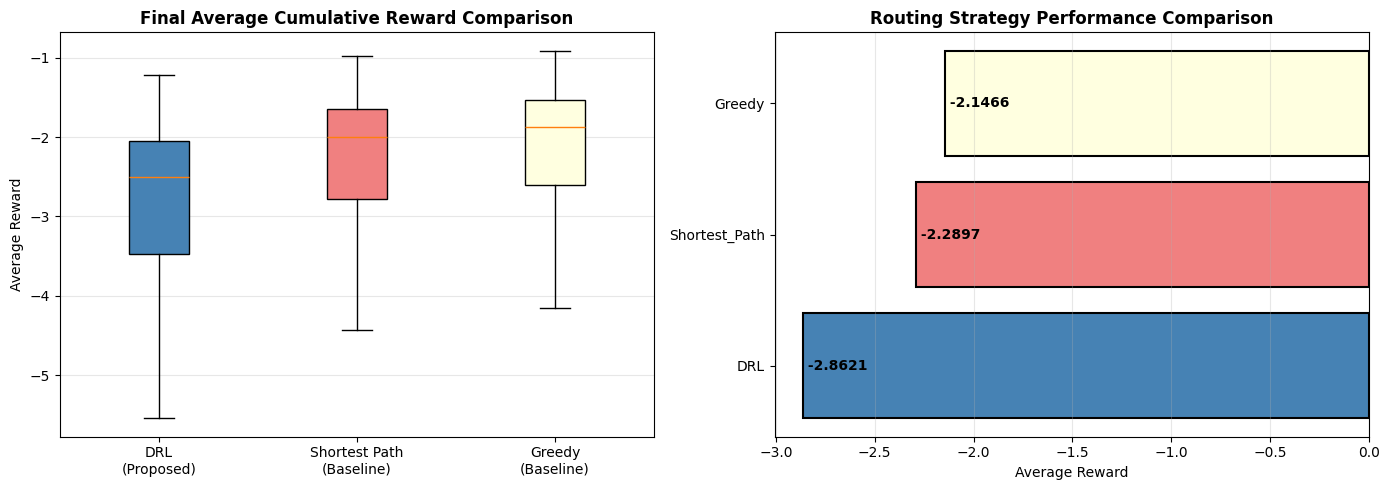

✓ Comparison visualization saved


In [43]:
# Comparative Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Reward Comparison Boxplot
comparison_data = [comparison_results['DRL'],
                  comparison_results['Shortest_Path'],
                  comparison_results['Greedy']]
labels = ['DRL\n(Proposed)', 'Shortest Path\n(Baseline)', 'Greedy\n(Baseline)']

bp = axes[0].boxplot(comparison_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'lightcoral', 'lightyellow']):
    patch.set_facecolor(color)

axes[0].set_title('Final Average Cumulative Reward Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Reward')
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Method Performance Summary
methods = ['DRL', 'Shortest_Path', 'Greedy'] # Changed 'Shortest Path' to 'Shortest_Path' to match the key in comparison_results
avg_rewards = [np.mean(comparison_results[m]) for m in methods]
colors = ['steelblue', 'lightcoral', 'lightyellow']

bars = axes[1].barh(methods, avg_rewards, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Average Reward')
axes[1].set_title('Routing Strategy Performance Comparison', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, avg_rewards)):
    axes[1].text(value, i, f' {value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('method_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Comparison visualization saved")

## 10. Key Performance Metrics Analysis

In [44]:
# Analyze Key Metrics from Dataset
print("\n=== KEY PERFORMANCE METRICS ANALYSIS ===")

# 1. End-to-End Delay Analysis
print("\n1. END-TO-END DELAY ANALYSIS")
delay_stats = df['packet_delay_ms'].describe()
print(f"   Mean Delay: {delay_stats['mean']:.2f} ms")
print(f"   Std Dev: {delay_stats['std']:.2f} ms")
print(f"   Min Delay: {delay_stats['min']:.2f} ms")
print(f"   Max Delay: {delay_stats['max']:.2f} ms")
print(f"   Median Delay: {df['packet_delay_ms'].median():.2f} ms")

# 2. Packet Delivery Ratio
print("\n2. PACKET DELIVERY RATIO")
pdr_stats = df['packet_delivery_ratio'].describe()
print(f"   Mean PDR: {pdr_stats['mean']:.4f}")
print(f"   Std Dev: {pdr_stats['std']:.4f}")
print(f"   Min PDR: {pdr_stats['min']:.4f}")
print(f"   Max PDR: {pdr_stats['max']:.4f}")

# 3. Link Stability Analysis
print("\n3. LINK STABILITY ANALYSIS")
stability_stats = df['link_stability_sec'].describe()
print(f"   Mean Stability: {stability_stats['mean']:.2f} sec")
print(f"   Std Dev: {stability_stats['std']:.2f} sec")
print(f"   Min Stability: {stability_stats['min']:.2f} sec")
print(f"   Max Stability: {stability_stats['max']:.2f} sec")

# 4. Traffic Density Distribution
print("\n4. TRAFFIC DENSITY DISTRIBUTION")
traffic_stats = df['traffic_density'].describe()
print(f"   Mean Density: {traffic_stats['mean']:.4f}")
print(f"   Std Dev: {traffic_stats['std']:.4f}")
print(f"   Min Density: {traffic_stats['min']:.4f}")
print(f"   Max Density: {traffic_stats['max']:.4f}")

# 5. Event Type Distribution
print("\n5. EMERGENCY EVENT DISTRIBUTION")
event_dist = df['event_type'].value_counts()
for event, count in event_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   {event}: {count} ({percentage:.2f}%)")

# 6. Action Distribution
print("\n6. ROUTING ACTION DISTRIBUTION")
action_dist = df['action_taken'].value_counts()
for action, count in action_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   {action}: {count} ({percentage:.2f}%)")


=== KEY PERFORMANCE METRICS ANALYSIS ===

1. END-TO-END DELAY ANALYSIS
   Mean Delay: 105.45 ms
   Std Dev: 54.76 ms
   Min Delay: 10.00 ms
   Max Delay: 199.98 ms
   Median Delay: 105.59 ms

2. PACKET DELIVERY RATIO
   Mean PDR: 0.7988
   Std Dev: 0.1159
   Min PDR: 0.6000
   Max PDR: 1.0000

3. LINK STABILITY ANALYSIS
   Mean Stability: 1.61 sec
   Std Dev: 0.81 sec
   Min Stability: 0.20 sec
   Max Stability: 3.00 sec

4. TRAFFIC DENSITY DISTRIBUTION
   Mean Density: 0.4982
   Std Dev: 0.2891
   Min Density: 0.0000
   Max Density: 1.0000

5. EMERGENCY EVENT DISTRIBUTION
   normal: 14091 (70.45%)
   ambulance_alert: 1945 (9.72%)
   traffic_update: 1441 (7.21%)
   accident: 1305 (6.53%)
   road_hazard: 1218 (6.09%)

6. ROUTING ACTION DISTRIBUTION
   straight: 5074 (25.37%)
   left: 5022 (25.11%)
   right: 4968 (24.84%)
   alternate_route: 4936 (24.68%)


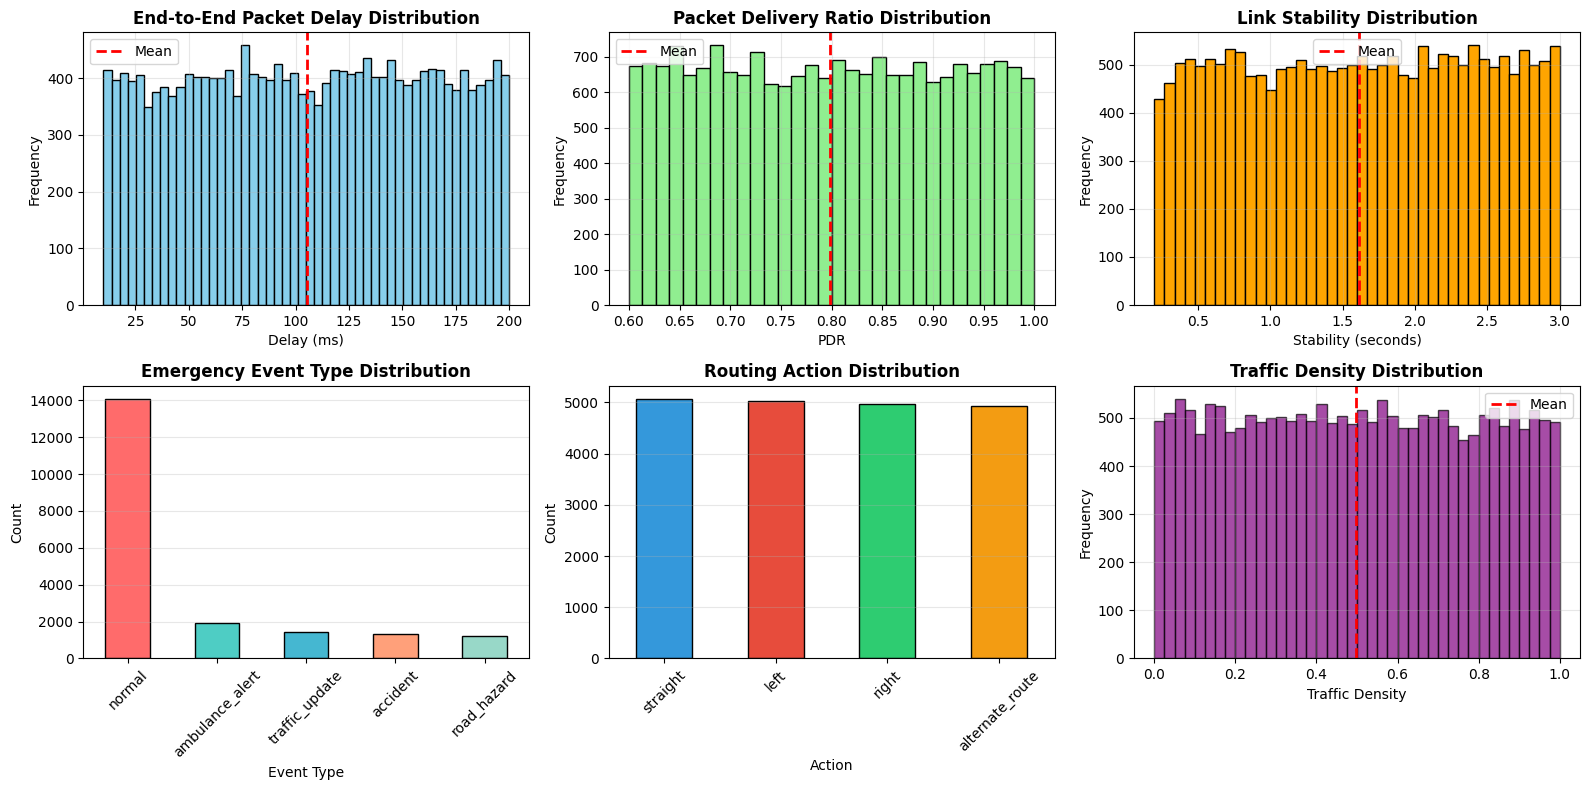

✓ Key metrics visualization saved


In [45]:
# Visualize Key Metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 1. Packet Delay Distribution
axes[0, 0].hist(df['packet_delay_ms'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].axvline(df['packet_delay_ms'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_title('End-to-End Packet Delay Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Delay (ms)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Packet Delivery Ratio Distribution
axes[0, 1].hist(df['packet_delivery_ratio'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].axvline(df['packet_delivery_ratio'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_title('Packet Delivery Ratio Distribution', fontweight='bold')
axes[0, 1].set_xlabel('PDR')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Link Stability Distribution
axes[0, 2].hist(df['link_stability_sec'], bins=40, color='orange', edgecolor='black')
axes[0, 2].axvline(df['link_stability_sec'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 2].set_title('Link Stability Distribution', fontweight='bold')
axes[0, 2].set_xlabel('Stability (seconds)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Event Type Distribution
event_counts = df['event_type'].value_counts()
colors_event = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
event_counts.plot(kind='bar', ax=axes[1, 0], color=colors_event[:len(event_counts)], edgecolor='black')
axes[1, 0].set_title('Emergency Event Type Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Event Type')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Action Distribution
action_counts = df['action_taken'].value_counts()
colors_action = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
action_counts.plot(kind='bar', ax=axes[1, 1], color=colors_action[:len(action_counts)], edgecolor='black')
axes[1, 1].set_title('Routing Action Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Action')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Traffic Density Distribution
axes[1, 2].hist(df['traffic_density'], bins=40, color='purple', alpha=0.7, edgecolor='black')
axes[1, 2].axvline(df['traffic_density'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 2].set_title('Traffic Density Distribution', fontweight='bold')
axes[1, 2].set_xlabel('Traffic Density')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('key_metrics_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Key metrics visualization saved")

In [46]:
# Save model and results
print("\n### SAVING RESULTS ###\n")

# Save trained model
agent.q_network.save('drl_emergency_routing_model.h5')
print("✓ Trained Q-Network saved: drl_emergency_routing_model.h5")

# Save training history
import json

training_history = {
    'episodes': NUM_EPISODES,
    'episode_rewards': episode_rewards,
    'episode_q_values': [float(q) for q in episode_q_values],
    'final_epsilon': float(agent.epsilon),
    'model_architecture': 'DQN (128-64-32 neurons)',
    'state_size': state_size,
    'action_size': action_size,
    'evaluation_results': {
        'avg_reward': float(evaluation_results['avg_reward']),
        'std_reward': float(evaluation_results['std_reward']),
        'avg_success_rate': float(evaluation_results['avg_success_rate'])
    }
}

with open('training_history.json', 'w') as f:
    json.dump(training_history, f, indent=4)

print("✓ Training history saved: training_history.json")
print("\n✓ All results and visualizations generated successfully!")


### SAVING RESULTS ###

✓ Trained Q-Network saved: drl_emergency_routing_model.h5
✓ Training history saved: training_history.json

✓ All results and visualizations generated successfully!
